In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib
plt.style.use('ggplot')
from matplotlib.pyplot import figure

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12,8) # Adjust the configuration of the plots I create

# Read in the data
df = pd.read_csv('/content/drive/MyDrive/PY/Data Analysis/Alex/Movie Industry/archive/movies.csv')

In [6]:
df


,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,More to Life,NaN,Drama,2020,"October 23, 2020 (United States)",3.1,18.0,Joseph Ebanks,Joseph Ebanks,Shannon Bond,United States,7000.0,NaN,NaN,90.0
7664,Dream Round,NaN,Comedy,2020,"February 7, 2020 (United States)",4.7,36.0,Dusty Dukatz,Lisa Huston,Michael Saquella,United States,NaN,NaN,Cactus Blue Entertainment,90.0
7665,Saving Mbango,NaN,Drama,2020,"April 27, 2020 (Cameroon)",5.7,29.0,Nkanya Nkwai,Lynno Lovert,Onyama Laura,United States,58750.0,NaN,Embi Productions,NaN
7666,It's Just Us,NaN,Drama,2020,"October 1, 2020 (United States)",NaN,NaN,James Randall,James Randall,Christina Roz,United States,15000.0,NaN,NaN,120.0


In [7]:
# Let's look at the data

df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [8]:
# Let's see if there is any missing data

for col in df.columns:
  pct_missing = np.mean(df[col].isnull())
  print('{} - {}%'.format(col, round(pct_missing*100)))

name - 0%
rating - 1%
genre - 0%
year - 0%
released - 0%
score - 0%
votes - 0%
director - 0%
writer - 0%
star - 0%
country - 0%
budget - 28%
gross - 2%
company - 0%
runtime - 0%


In [9]:
# Data types for my columns
df.dtypes

,0
name,object
rating,object
genre,object
year,int64
released,object
score,float64
votes,float64
director,object
writer,object
star,object


In [10]:
# Change data type of columns

# Eliminate rows where budget or gross have NaN and make an explicit copy
df = df.dropna(subset=['budget', 'gross']).copy()

# Now change to int
df['budget'] = df['budget'].astype('int64')
df['gross'] = df['gross'].astype('int64')

In [11]:
df

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344,Orion Pictures,98.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7648,Bad Boys for Life,R,Action,2020,"January 17, 2020 (United States)",6.6,140000.0,Adil El Arbi,Peter Craig,Will Smith,United States,90000000,426505244,Columbia Pictures,124.0
7649,Sonic the Hedgehog,PG,Action,2020,"February 14, 2020 (United States)",6.5,102000.0,Jeff Fowler,Pat Casey,Ben Schwartz,United States,85000000,319715683,Paramount Pictures,99.0
7650,Dolittle,PG,Adventure,2020,"January 17, 2020 (United States)",5.6,53000.0,Stephen Gaghan,Stephen Gaghan,Robert Downey Jr.,United States,175000000,245487753,Universal Pictures,101.0
7651,The Call of the Wild,PG,Adventure,2020,"February 21, 2020 (United States)",6.8,42000.0,Chris Sanders,Michael Green,Harrison Ford,Canada,135000000,111105497,20th Century Studios,100.0


In [12]:
df.dtypes


,0
name,object
rating,object
genre,object
year,int64
released,object
score,float64
votes,float64
director,object
writer,object
star,object


In [59]:
# Create correct Year column

df['yearcorrect'] = df['released'].astype(str).str[:4]

df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,yearcorrect
5445,387,5,0,2009,528,7.8,1100000.0,787,1265,1538,47,237000000,2847246203,1388,162.0,528
7445,389,5,0,2019,138,8.4,903000.0,106,515,1474,47,356000000,2797501328,987,181.0,138
3045,4923,5,6,1997,535,7.8,1100000.0,787,1265,1076,47,200000000,2201647264,1388,194.0,535
6663,3656,5,0,2015,530,7.8,876000.0,770,1810,357,47,245000000,2069521700,949,138.0,530
7244,390,5,0,2018,146,8.4,897000.0,106,515,1474,47,321000000,2048359754,987,149.0,146


In [60]:
# View the top 5 highest-grossing movies without bloating file size
df.sort_values(by=['gross'], ascending=False).head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,yearcorrect
5445,387,5,0,2009,528,7.8,1100000.0,787,1265,1538,47,237000000,2847246203,1388,162.0,528
7445,389,5,0,2019,138,8.4,903000.0,106,515,1474,47,356000000,2797501328,987,181.0,138
3045,4923,5,6,1997,535,7.8,1100000.0,787,1265,1076,47,200000000,2201647264,1388,194.0,535
6663,3656,5,0,2015,530,7.8,876000.0,770,1810,357,47,245000000,2069521700,949,138.0,530
7244,390,5,0,2018,146,8.4,897000.0,106,515,1474,47,321000000,2048359754,987,149.0,146


In [15]:
# CAUTION! this line will increase the document size!! (Use it carefully)

# pd.set_option('display.max_rows', None)

In [16]:
df = df.sort_values(by=['gross'], inplace=False, ascending=False)

In [61]:
# Drop duplicates and view the top 5 company names alphabetically
df['company'].drop_duplicates().sort_values(ascending=False).head()

,company
7129,1480
5664,1479
4007,1478
6793,1477
6420,1476


In [62]:
# View the top 5 company values sorted in descending order
df['company'].sort_values(ascending=False).head()

,company
7129,1480
5664,1479
4007,1478
6793,1477
6420,1476


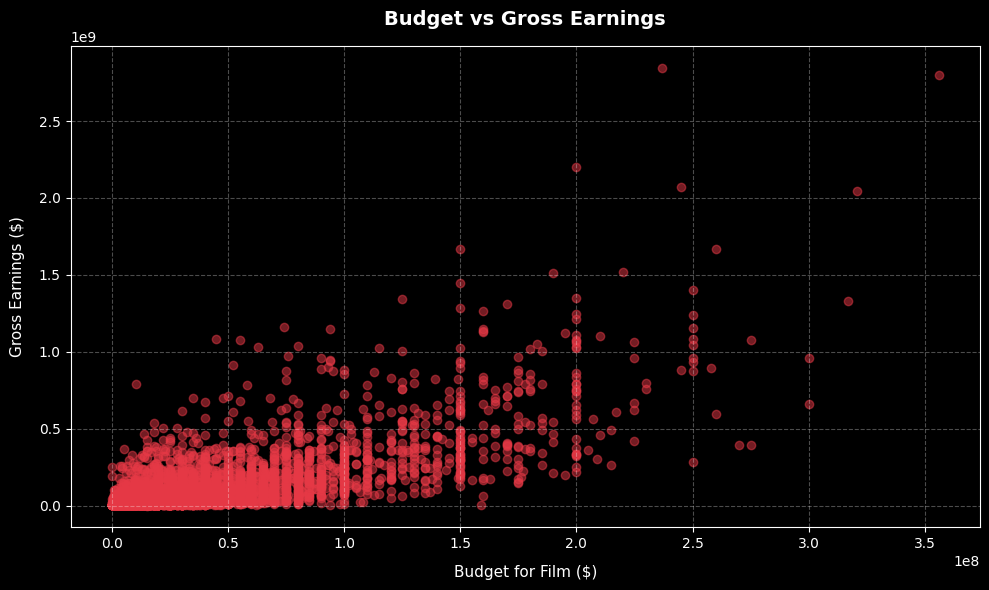

In [63]:
# Scatter plot with Budget vs Gross Earnings
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

plt.scatter(x=df['budget'], y=df['gross'], alpha=0.5, color='#e63946')
plt.title('Budget vs Gross Earnings', fontsize=14, pad=15, weight='bold')
plt.xlabel('Budget for Film ($)', fontsize=11, labelpad=10)
plt.ylabel('Gross Earnings ($)', fontsize=11, labelpad=10)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Reset default theme
plt.style.use('default')

In [21]:
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,yearcorrect
5445,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",7.8,1100000.0,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162.0,Dece
7445,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181.0,Apri
3045,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",7.8,1100000.0,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194.0,Dece
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",7.8,876000.0,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138.0,Dece
7244,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8.4,897000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149.0,Apri


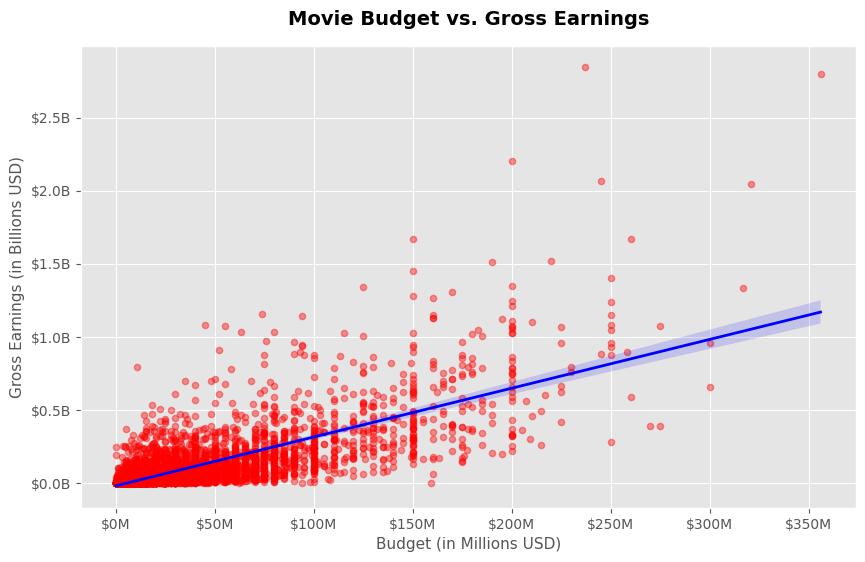

In [22]:
import matplotlib.ticker as ticker

# Set figure size
plt.figure(figsize=(10, 6))

# Regression plot with transparency adjustment
sns.regplot(
    x='budget',
    y='gross',
    data=df,
    scatter_kws={'color': 'red', 'alpha': 0.4, 's': 20}, # 's' adjusts point size
    line_kws={'color': 'blue', 'linewidth': 2}
)

# Titles and labels
plt.title('Movie Budget vs. Gross Earnings', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Budget (in Millions USD)', fontsize=11)
plt.ylabel('Gross Earnings (in Billions USD)', fontsize=11)

# Format axes
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x*1e-6:.0f}M'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f'${y*1e-9:.1f}B'))

plt.show()

In [23]:
# Lets start looking at correlation
df.corr(numeric_only=True)

,year,score,votes,budget,gross,runtime
year,1.000000,0.055174,0.205758,0.327781,0.274264,0.074203
score,0.055174,1.000000,0.473809,0.071792,0.222143,0.414580
votes,0.205758,0.473809,1.000000,0.440021,0.614904,0.352437
budget,0.327781,0.071792,0.440021,1.000000,0.740395,0.318595
gross,0.274264,0.222143,0.614904,0.740395,1.000000,0.275596
runtime,0.074203,0.414580,0.352437,0.318595,0.275596,1.000000


In [24]:
df.corr(method='pearson', numeric_only=True)

,year,score,votes,budget,gross,runtime
year,1.000000,0.055174,0.205758,0.327781,0.274264,0.074203
score,0.055174,1.000000,0.473809,0.071792,0.222143,0.414580
votes,0.205758,0.473809,1.000000,0.440021,0.614904,0.352437
budget,0.327781,0.071792,0.440021,1.000000,0.740395,0.318595
gross,0.274264,0.222143,0.614904,0.740395,1.000000,0.275596
runtime,0.074203,0.414580,0.352437,0.318595,0.275596,1.000000


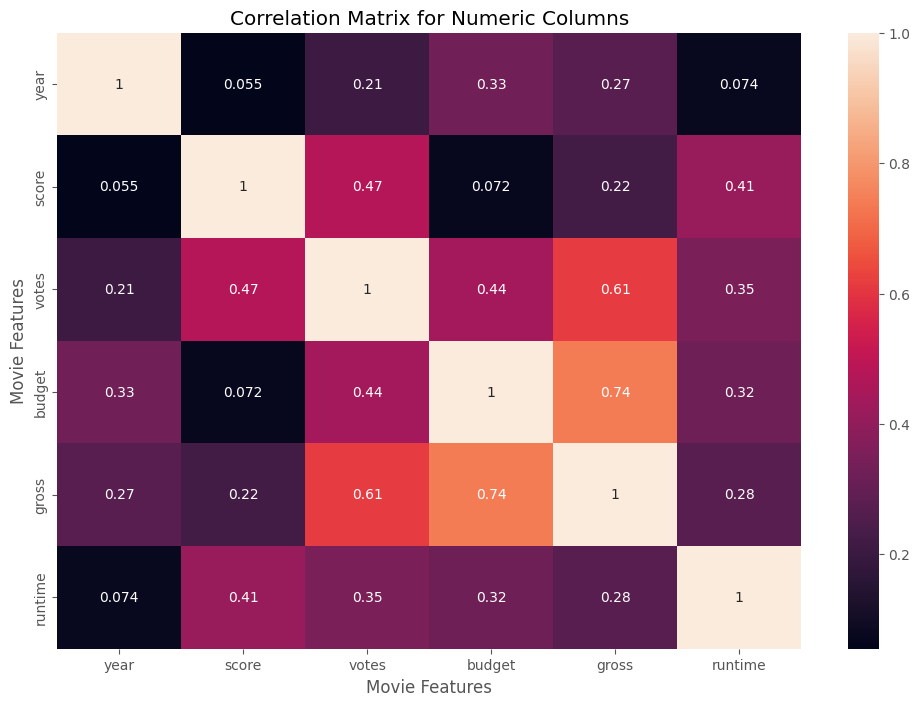

In [25]:
correlation_matrix = df.corr(method='pearson', numeric_only=True)

sns.heatmap(correlation_matrix, annot=True)

plt.title('Correlation Matrix for Numeric Columns')

plt.xlabel('Movie Features')

plt.ylabel('Movie Features')

plt.show()


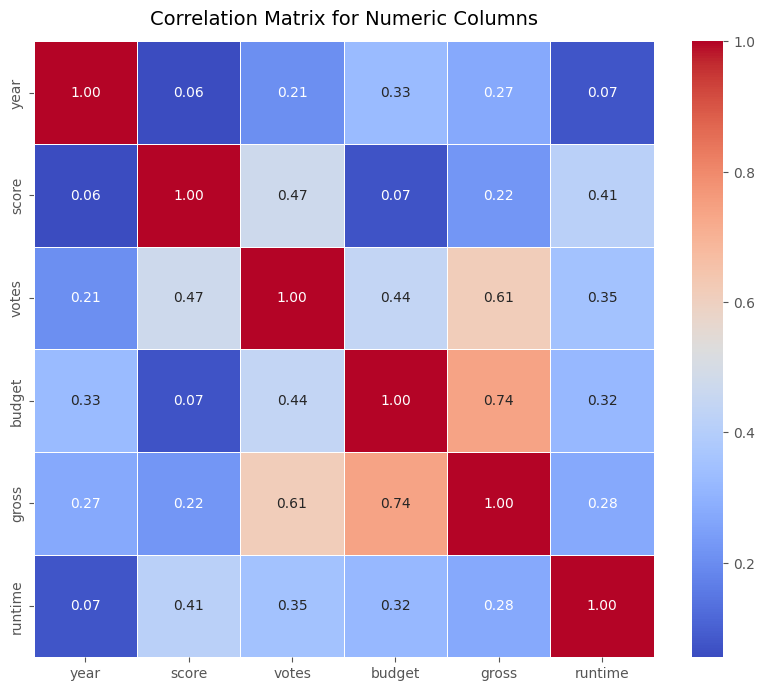

In [26]:
# Custom heatmap

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',        # Keeps all numbers to 2 decimal places (e.g., 0.07 instead of 0.072)
    cmap='coolwarm',   # Red-blue palette makes strong/weak correlations pop even more
    linewidths=0.5
)
plt.title('Correlation Matrix for Numeric Columns', fontsize=14, pad=12)
plt.show()



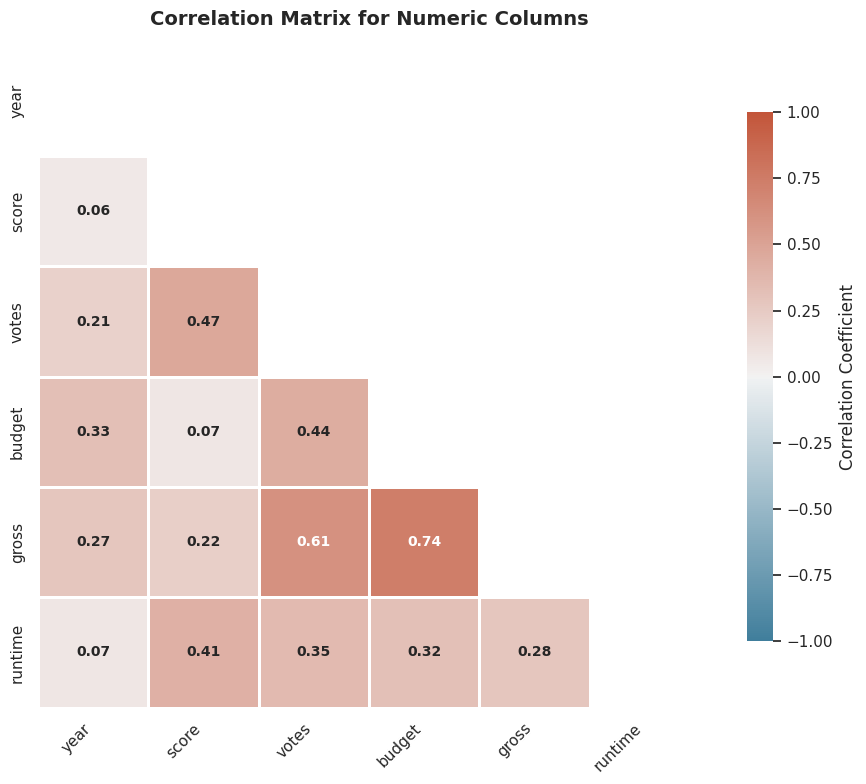

In [27]:
# Masked Upper Triangle

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set overall aesthetic style
sns.set_theme(style="white")

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(10, 8))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(
    correlation_matrix,
    mask=mask,
    cmap=sns.diverging_palette(230, 20, as_cmap=True),  # Elegant Blue-Red palette
    vmax=1.0,
    vmin=-1.0,
    center=0,
    annot=True,
    fmt=".2f",
    square=True,  # Forces cells to be perfectly square
    linewidths=0.75,
    cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"},
    annot_kws={"size": 10, "weight": "bold"},
)

plt.title(
    "Correlation Matrix for Numeric Columns",
    fontsize=14,
    pad=15,
    weight="bold",
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

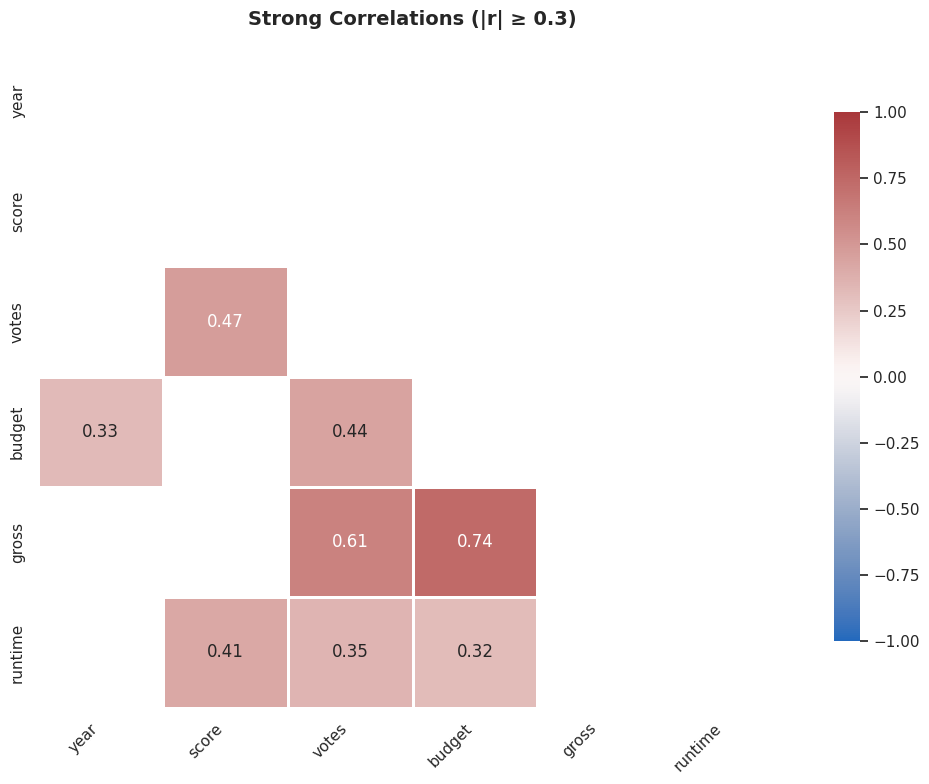

In [28]:
# Highlight Only Strong Correlations

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Create mask for diagonal/upper triangle AND weak correlations
threshold = 0.3  # Change this to your preferred strength
weak_corr_mask = (np.abs(correlation_matrix) < threshold) | np.triu(
    np.ones_like(correlation_matrix, dtype=bool)
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    mask=weak_corr_mask,
    cmap="vlag",  # Sleek diverging blue-red palette
    vmax=1.0,
    vmin=-1.0,
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=1,
    linecolor="white",
    cbar_kws={"shrink": 0.8},
)

plt.title(
    f"Strong Correlations (|r| ≥ {threshold})", fontsize=14, pad=15, weight="bold"
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

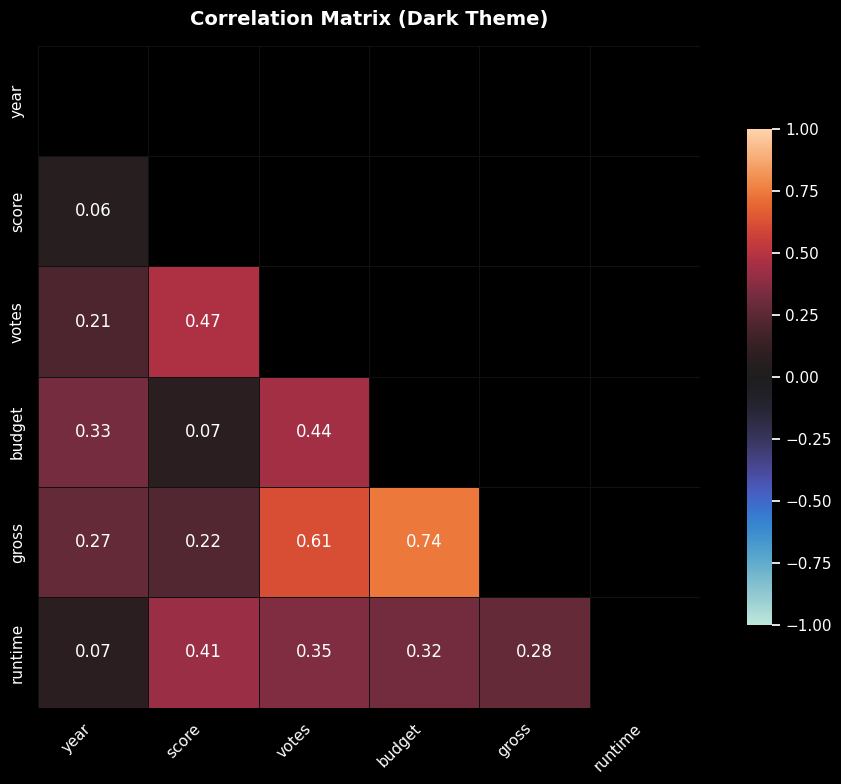

In [29]:
# Modern Dark Mode Theme

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set dark theme context
plt.style.use("dark_background")

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    mask=mask,
    cmap="icefire",  # High-contrast dark-mode palette
    vmax=1.0,
    vmin=-1.0,
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    linecolor="#111111",
    cbar_kws={"shrink": 0.75},
)

plt.title(
    "Correlation Matrix (Dark Theme)",
    fontsize=14,
    pad=15,
    weight="bold",
    color="white",
)
plt.xticks(rotation=45, ha="right", color="white")
plt.yticks(color="white")
plt.tight_layout()
plt.show()

# Reset default background style afterwards
plt.style.use("default")

In [30]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

# Ensure correlation matrix is calculated
correlation_matrix = df.corr(method='pearson', numeric_only=True)

In [31]:
# Create interactive heatmap
fig = px.imshow(
    correlation_matrix.round(2),
    text_auto=True,  # Displays numbers directly on the tiles
    aspect="auto",
    color_continuous_scale="RdBu_r",  # Red-Blue scale (reversed so 1.0 is dark red/blue)
    zmin=-1,
    zmax=1,
    title="Interactive Correlation Matrix (Hover for Details)",
    labels=dict(color="Correlation"),
)

# Custom layout and formatting
fig.update_layout(
    width=750,
    height=650,
    title_x=0.5,  # Center title
    font=dict(family="Arial, sans-serif", size=12),
    xaxis_title="Movie Features",
    yaxis_title="Movie Features",
)

# Update hover template for detailed inspection
fig.update_traces(
    hovertemplate="<b>X Feature:</b> %{x}<br>"
    + "<b>Y Feature:</b> %{y}<br>"
    + "<b>Correlation:</b> %{z:.3f}<extra></extra>"
)

fig.show()

In [32]:
# Advanced Interactive Triangular Heatmap (Masked)

# Create a mask array for the upper triangle
corr_values = correlation_matrix.values.copy()
mask = np.triu(np.ones_like(corr_values, dtype=bool))
corr_values[mask] = np.nan  # Mask out upper triangle with NaNs

# Extract column/index names
features = correlation_matrix.columns.tolist()

# Build interactive heatmap object
fig = go.Figure(
    data=go.Heatmap(
        z=corr_values,
        x=features,
        y=features,
        colorscale="IceFire",
        zmin=-1,
        zmax=1,
        text=np.nan_to_num(corr_values).round(2),
        texttemplate="%{text}",
        textfont={"size": 11, "color": "white"},
        hoverongaps=False,
        hovertemplate="<b>Feature 1:</b> %{x}<br><b>Feature 2:</b> %{y}<br><b>Correlation:</b> %{z:.2f}<extra></extra>",
    )
)

fig.update_layout(
    title="Interactive Triangular Correlation Heatmap",
    title_x=0.5,
    width=750,
    height=650,
    template="plotly_dark",  # Sleek dark mode template
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=False, autorange="reversed"),  # Keep top-to-bottom orientation
)

fig.show()

In [34]:
# Looks at company

df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,yearcorrect
5445,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",7.8,1100000.0,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162.0,Dece
7445,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181.0,Apri
3045,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",7.8,1100000.0,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194.0,Dece
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",7.8,876000.0,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138.0,Dece
7244,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8.4,897000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149.0,Apri


In [35]:
df.sort_values(by='budget', ascending=False).head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,yearcorrect
7445,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181.0,Apri
7244,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8.4,897000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149.0,Apri
7075,Star Wars: Episode VIII - The Last Jedi,PG-13,Action,2017,"December 15, 2017 (United States)",7.0,581000.0,Rian Johnson,Rian Johnson,Daisy Ridley,United States,317000000,1332698830,Walt Disney Pictures,152.0,Dece
7066,Justice League,PG-13,Action,2017,"November 17, 2017 (United States)",6.1,418000.0,Zack Snyder,Jerry Siegel,Ben Affleck,United States,300000000,657926987,Warner Bros.,120.0,Nove
5060,Pirates of the Caribbean: at World's End,PG-13,Action,2007,"May 25, 2007 (United States)",7.1,608000.0,Gore Verbinski,Ted Elliott,Johnny Depp,United States,300000000,960996492,Walt Disney Pictures,169.0,May


In [64]:
# Create an explicit copy to preserve original df text columns
df_numerized = df.copy()

# Numerize all text/object columns in one clean line
df_numerized = df_numerized.apply(lambda col: col.astype('category').cat.codes if col.dtype == 'object' else col)

# View preview safely without bloating file size
df_numerized.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,yearcorrect
5445,387,5,0,2009,528,7.8,1100000.0,787,1265,1538,47,237000000,2847246203,1388,162.0,2043
7445,389,5,0,2019,138,8.4,903000.0,106,515,1474,47,356000000,2797501328,987,181.0,424
3045,4923,5,6,1997,535,7.8,1100000.0,787,1265,1076,47,200000000,2201647264,1388,194.0,2051
6663,3656,5,0,2015,530,7.8,876000.0,770,1810,357,47,245000000,2069521700,949,138.0,2046
7244,390,5,0,2018,146,8.4,897000.0,106,515,1474,47,321000000,2048359754,987,149.0,513


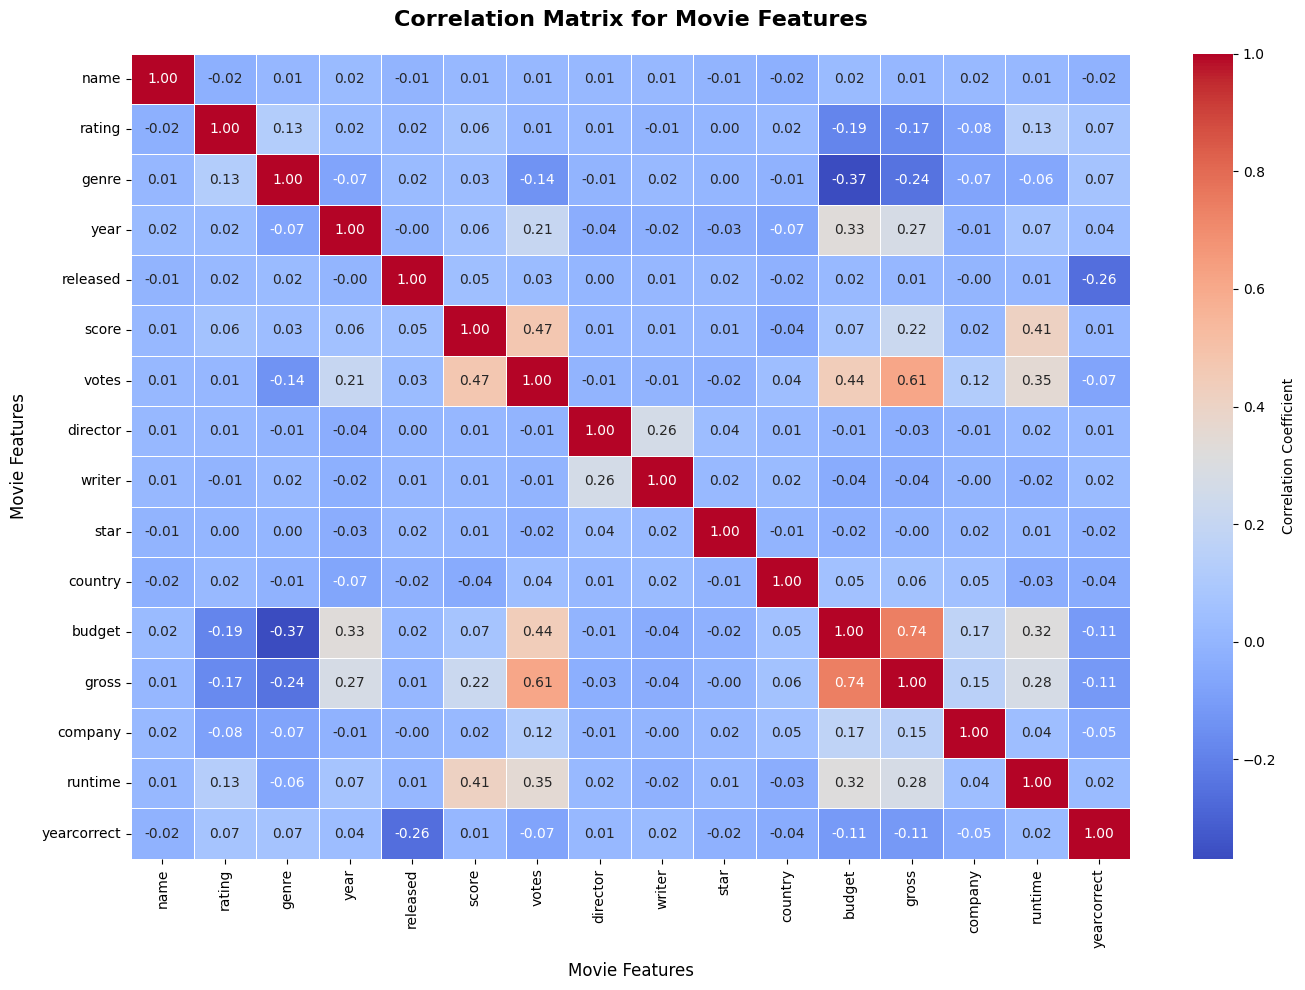

In [65]:
# Calculate correlation matrix
correlation_matrix = df_numerized.corr(method='pearson')

# Set up figure size
plt.figure(figsize=(14, 10))

# Custom Seaborn Heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",               # Format numbers to 2 decimal places (e.g., 0.74)
    cmap='coolwarm',         # High contrast: red for positive, blue for negative
    linewidths=0.5,          # Subtle grid lines between cells
    cbar_kws={'label': 'Correlation Coefficient'}
)

# Titles and labels
plt.title('Correlation Matrix for Movie Features', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Movie Features', fontsize=12, labelpad=10)
plt.ylabel('Movie Features', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

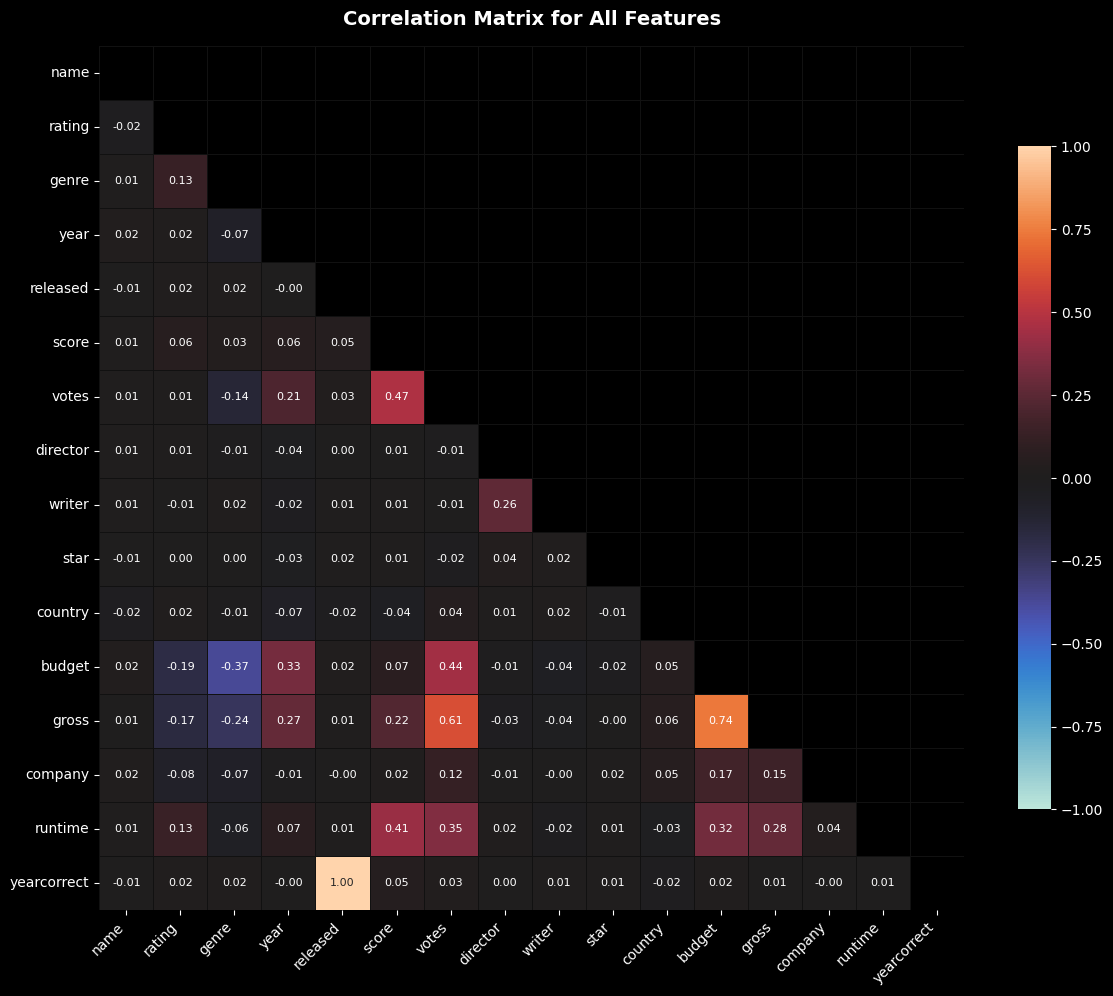

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. All correlations
correlation_matrix = df_numerized.corr(method='pearson')

# 2. Dark Theme
plt.style.use("dark_background")

# 3. Mask
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# 4. Dimensions
plt.figure(figsize=(12, 10))

# 5. Heatmap
sns.heatmap(
    correlation_matrix,
    mask=mask,
    cmap="icefire",
    vmax=1.0,
    vmin=-1.0,
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    linecolor="#111111",
    cbar_kws={"shrink": 0.75},
    annot_kws={"size": 8}  # Small letters
)

plt.title("Correlation Matrix for All Features", fontsize=14, pad=15, weight="bold")
plt.xticks(rotation=45, ha="right", color="white")
plt.yticks(color="white")
plt.tight_layout()
plt.show()

# Restaurar estilo por defecto
plt.style.use("default")

In [66]:
# Save correlation matrix to a variable
correlation_matrix = df_numerized.corr(method='pearson')

# View the first 5 rows safely
correlation_matrix.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,yearcorrect
name,1.000000,-0.023013,0.009617,0.024435,-0.005896,0.014955,0.012915,0.013699,0.011602,-0.007109,-0.024555,0.023698,0.005966,0.021209,0.010800,-0.015141
rating,-0.023013,1.000000,0.128102,0.022668,0.018836,0.059550,0.009255,0.014847,-0.006923,0.003737,0.020148,-0.186892,-0.168814,-0.082189,0.133239,0.073567
genre,0.009617,0.128102,1.000000,-0.073026,0.021712,0.034061,-0.136457,-0.009303,0.017500,0.002619,-0.010847,-0.368900,-0.244380,-0.073293,-0.060186,0.069487
year,0.024435,0.022668,-0.073026,1.000000,-0.001481,0.055174,0.205758,-0.036936,-0.024568,-0.032770,-0.066662,0.327781,0.274264,-0.013062,0.074203,0.036802
released,-0.005896,0.018836,0.021712,-0.001481,1.000000,0.046424,0.029029,0.003341,0.008514,0.015363,-0.017231,0.019888,0.008614,-0.002927,0.008619,-0.259779


In [67]:
correlation_mat = df_numerized.corr()
corr_pairs = correlation_mat.unstack()

# View the top 5 pairs safely
corr_pairs.head()

name  name        1.000000
      rating     -0.023013
      genre       0.009617
      year        0.024435
      released   -0.005896
dtype: float64

In [68]:
sorted_pairs = corr_pairs.sort_values()

# View top 10 lowest correlations safely
sorted_pairs.head(10)

genre        budget        -0.368900
budget       genre         -0.368900
yearcorrect  released      -0.259779
released     yearcorrect   -0.259779
genre        gross         -0.244380
gross        genre         -0.244380
budget       rating        -0.186892
rating       budget        -0.186892
             gross         -0.168814
gross        rating        -0.168814
dtype: float64

In [69]:
# Filter for strong correlations (r > 0.5)
high_corr = sorted_pairs[(sorted_pairs) > 0.5]

# View the top high correlations safely
high_corr.head(10)

,,0
votes,gross,0.614904
gross,votes,0.614904
budget,gross,0.740395
gross,budget,0.740395
director,director,1.000000
votes,votes,1.000000
released,released,1.000000
score,score,1.000000
rating,rating,1.000000
name,name,1.000000


In [56]:
# 1. Unstack correlation matrix
corr_pairs = df_numerized.corr().unstack()

# 2. Sort values descending
sorted_pairs = corr_pairs.sort_values(ascending=False)

# 3. Remove self-correlations (A == B) and mirrored duplicates (A < B)
clean_pairs = sorted_pairs[
    sorted_pairs.index.get_level_values(0) < sorted_pairs.index.get_level_values(1)
]

# 4. Filter for strong correlations (> 0.5)
high_corr = clean_pairs[clean_pairs > 0.5]

print("Top Correlations (> 0.5):")
print(high_corr)

Top Correlations (> 0.5):
released  yearcorrect    0.996190
budget    gross          0.740395
gross     votes          0.614904
dtype: float64


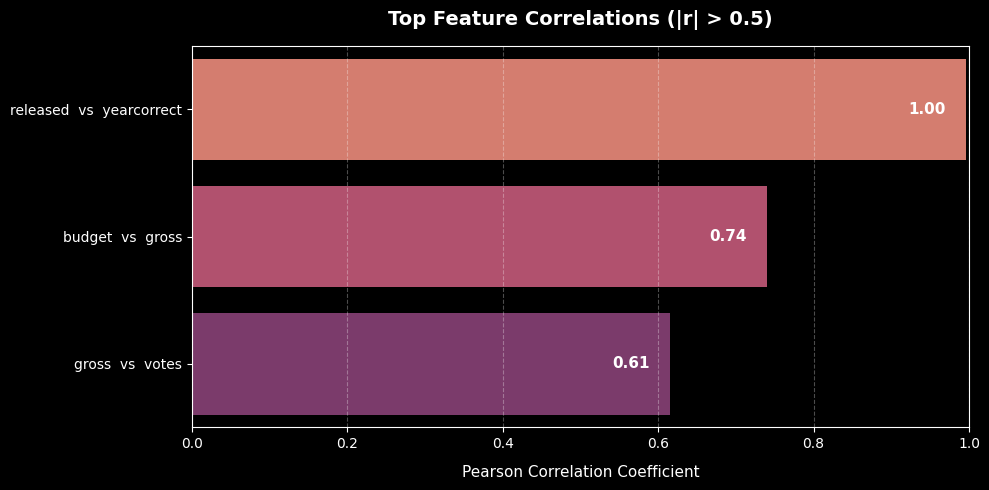

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Enable Dark Theme
plt.style.use("dark_background")

plt.figure(figsize=(10, 5))

# Convert Series to DataFrame for Seaborn plotting
high_corr_df = high_corr.reset_index()
high_corr_df.columns = ["Feature 1", "Feature 2", "Correlation"]
high_corr_df["Pair"] = (
    high_corr_df["Feature 1"] + "  vs  " + high_corr_df["Feature 2"]
)

# Horizontal Bar Plot
ax = sns.barplot(
    x="Correlation",
    y="Pair",
    data=high_corr_df,
    palette="flare",  # High-contrast vibrant dark palette
    hue="Pair",
    legend=False,
)

# Annotate exact correlation values on the bars
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f"{width:.2f}",
        (width - 0.05, p.get_y() + p.get_height() / 2.0),
        ha="center",
        va="center",
        fontsize=11,
        color="white",
        weight="bold",
    )

# Formatting
plt.title(
    "Top Feature Correlations (|r| > 0.5)", fontsize=14, pad=15, weight="bold"
)
plt.xlabel("Pearson Correlation Coefficient", fontsize=11, labelpad=10)
plt.ylabel("", fontsize=11)
plt.xlim(0, 1)  # Correlation range from 0 to 1
plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# Reset default background
plt.style.use("default")

In [54]:
# 1. Unstack the correlation matrix into pairs
corr_pairs = df_numerized.corr().unstack()

# 2. Sort pairs in descending order (highest correlations first)
sorted_pairs = corr_pairs.sort_values(ascending=False)

# 3. Filter out self-correlations (where feature_x == feature_y)
non_self = sorted_pairs[
    sorted_pairs.index.get_level_values(0)
    != sorted_pairs.index.get_level_values(1)
]

# 4. Remove mirrored duplicate pairs (keeps (A, B), removes (B, A))
high_corr = non_self[
    non_self.index.get_level_values(0) < non_self.index.get_level_values(1)
]

# Display the top 10 highest correlations
print("Top 10 Feature Correlations:")
print(high_corr.head(10))

Top 10 Feature Correlations:
released  yearcorrect    0.996190
budget    gross          0.740395
gross     votes          0.614904
score     votes          0.473809
budget    votes          0.440021
runtime   score          0.414580
          votes          0.352437
budget    year           0.327781
          runtime        0.318595
gross     runtime        0.275596
dtype: float64


In [55]:
# Filtering for Strong Relationships Only

# Filter for strong positive correlations (|r| > 0.4)
strong_pairs = high_corr[abs(high_corr) > 0.4]

print("Strongest Correlations (|r| > 0.4):")
print(strong_pairs)

Strongest Correlations (|r| > 0.4):
released  yearcorrect    0.996190
budget    gross          0.740395
gross     votes          0.614904
score     votes          0.473809
budget    votes          0.440021
runtime   score          0.414580
dtype: float64


In [58]:
# Extract Lowest Correlations

# Extract the lowest/weakest correlations close to 0
weak_corr = clean_pairs[abs(clean_pairs) < 0.1]
print("Weakest Correlations (|r| < 0.1):")
print(weak_corr.head(10))

Weakest Correlations (|r| < 0.1):
runtime   year           0.074203
budget    score          0.071792
country   gross          0.060929
rating    score          0.059550
score     year           0.055174
budget    country        0.054372
company   country        0.049559
released  score          0.046424
score     yearcorrect    0.045603
country   votes          0.042146
dtype: float64
